# 01 - Correccion de senales sismicas

Casos de uso: parametros manuales, recomendacion automatica y procesamiento compatible de pares NS/EW.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import signalprocessor as sp
from signalprocessor.plotting import plot_correction_summary

plt.rcParams['figure.dpi'] = 120

## Datos

Los CSV tienen columnas `tiempo_s, aceleracion_g`. La libreria convierte internamente a m/s2.

In [2]:
cfg = sp.load_json(ROOT / 'examples/config/correction.json')
lima_ns = sp.read_motion_csv(ROOT / 'examples/data/motion/LIMANS.csv', acceleration_unit='g', component='NS')
lima_ew = sp.read_motion_csv(ROOT / 'examples/data/motion/LIMAEW.csv', acceleration_unit='g', component='EW')

pd.DataFrame([sp.motion_summary(lima_ns.acceleration_mps2, lima_ns.dt)])

,PGA_mps2,PGA_g,PGV_mps,PGD_m,final_velocity_mps,final_displacement_m,arias_intensity_mps,CAV_mps,post_event_velocity_slope_mps2,post_event_displacement_slope_mps,D_5_75,D_5_95,D_20_80
0,2.018759,0.205856,0.156415,0.050369,-0.000361,-0.004619,1.875107,22.125088,-0.000181,-0.000053,33.320341,45.879512,29.615081


## Caso A: parametros directos del usuario

El usuario fija baseline polinomial y filtro bandpass. Este modo es reproducible y no busca parametros.

In [3]:
manual = sp.process_motion(
    lima_ns,
    baseline={'method': 'polynomial', 'order': 1},
    filtering={'highpass_hz': 0.26, 'lowpass_hz': 20.0, 'order': 4},
    recommend=False,
)
manual.summary()

,record_id,baseline,highpass_hz,lowpass_hz,PGA_g,PGV_mps,PGD_m,final_velocity_mps,final_displacement_m,arias_intensity_mps,D_5_95,CAV_mps
0,LIMANS,manual_weighted_polynomial_order_1,0.26,20.0,0.207473,0.171045,0.041309,0.000046,0.040506,1.872929,45.852842,22.090061


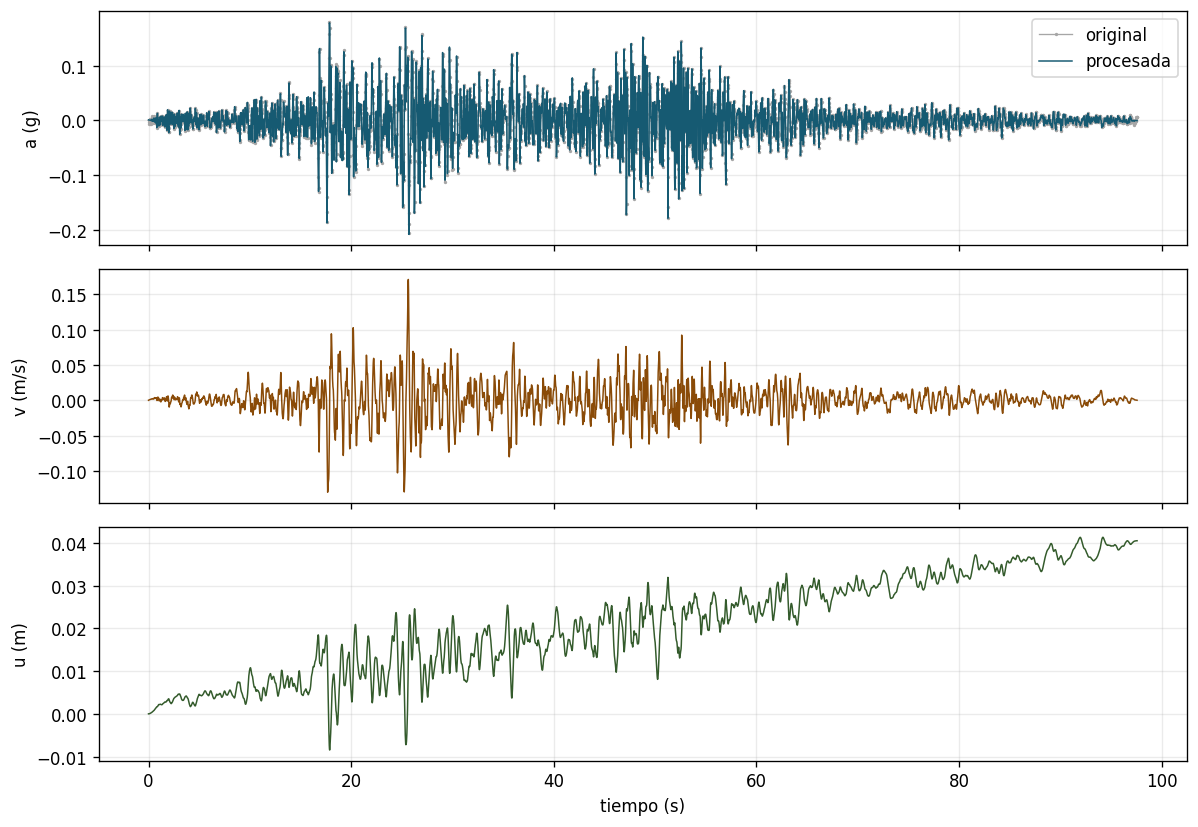

In [4]:
plot_correction_summary(manual);

## Caso B: recomendacion automatica

El motor detecta ventanas por Arias, evalua modelos de linea base globales y escoge el filtro high-pass mas bajo que pasa el control de desplazamiento.

In [5]:
recommended = sp.process_motion(lima_ns, config=cfg, recommend=True)
display(recommended.summary())
display(recommended.candidate_table.head(8))

,record_id,baseline,highpass_hz,lowpass_hz,PGA_g,PGV_mps,PGD_m,final_velocity_mps,final_displacement_m,arias_intensity_mps,D_5_95,CAV_mps
0,LIMANS,constant_velocity_final,0.287042,18.75,0.207386,0.17046,0.027545,-0.000471,-0.02616,1.872684,45.850799,22.088672


,name,complexity,score,passed,removed_mean_mps2,PGA_g,PGV_mps,PGD_m,final_velocity_mps,final_displacement_m,post_event_velocity_slope_mps2
0,constant_velocity_final,1,0.154517,True,0.000363,0.205856,0.156440,0.050055,-2.666471e-04,5.466321e-06,-0.000180
1,constrained_polynomial_vu_final,3,0.450844,True,0.000363,0.205856,0.156355,0.051364,4.044074e-15,1.354700e-13,-0.000170
2,pre_event_mean_only,0,2.449265,False,0.000363,0.205893,0.160426,1.734327,-3.582081e-02,-1.734327e+00,-0.000544
3,weighted_polynomial_order_0,1,2.673999,False,0.000363,0.205900,0.161561,2.039929,-4.208572e-02,-2.039929e+00,-0.000608
4,velocity_trend_derivative,3,2.751212,False,0.000363,0.205813,0.169608,1.792758,2.546537e-02,1.792758e+00,-0.000187
5,weighted_polynomial_order_1,2,2.839872,False,0.000363,0.205907,0.163427,2.296652,-4.389543e-02,-2.296652e+00,-0.000542
6,weighted_polynomial_order_2,3,3.641751,False,0.000363,0.206002,0.166918,5.350914,-9.938908e-02,-5.350914e+00,-0.000178


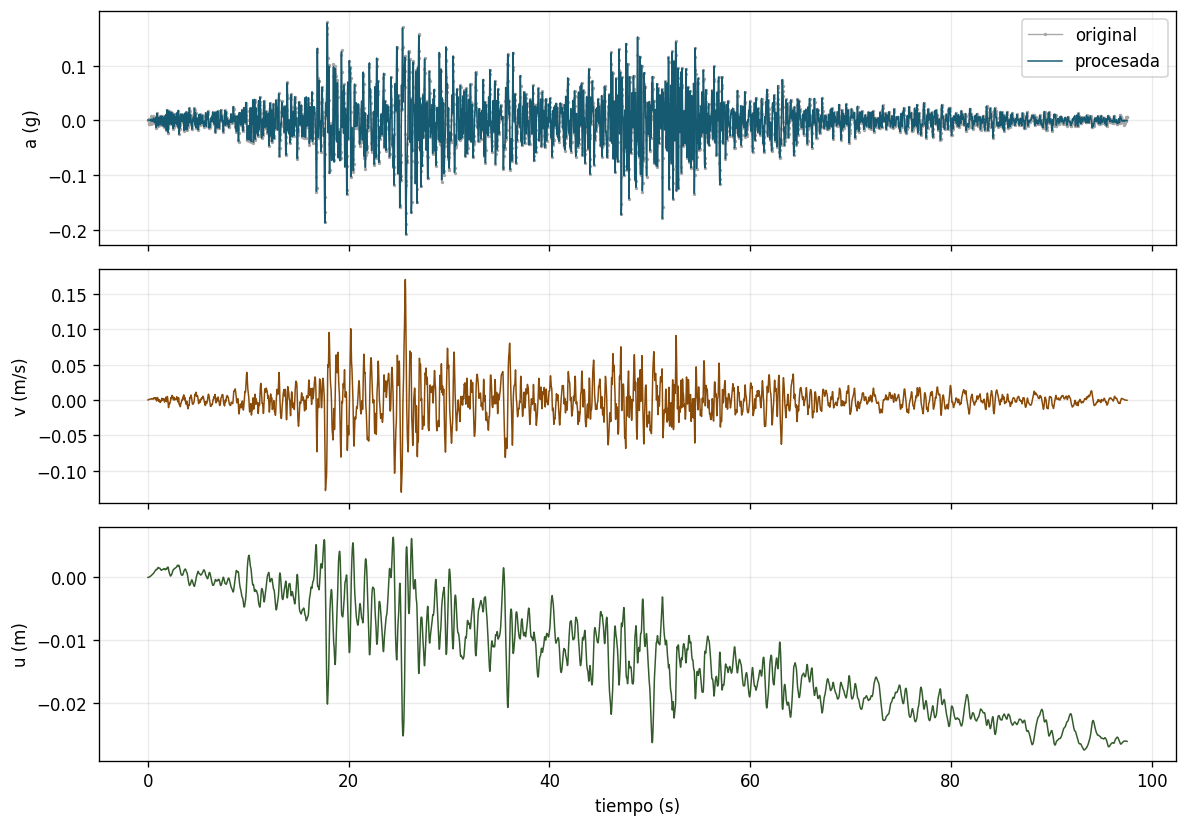

In [6]:
plot_correction_summary(recommended);

## Caso C: par NS/EW con filtro compartido

Para pares horizontales se recomienda usar cortes compatibles si se van a rotar, combinar o comparar direccionalmente.

In [7]:
pair = sp.process_pair(lima_ns, lima_ew, config=cfg, recommend=True, shared_filter=True, pair_id='LIMA')
pair.summary()

,pair_id,record_id,baseline,highpass_hz,lowpass_hz,PGA_g,PGV_mps,PGD_m,final_velocity_mps,final_displacement_m,arias_intensity_mps,D_5_95,CAV_mps
0,LIMA,LIMANS,constant_velocity_final,0.35839,18.75,0.207581,0.167080,0.114261,-0.001223,-0.114261,1.871776,45.845684,22.081864
1,LIMA,LIMAEW,constant_velocity_final,0.35839,18.75,0.205349,0.143826,0.027681,-0.001309,-0.018582,1.495752,44.504442,19.286615


## Comparacion de casos de uso

In [8]:
comparison = pd.concat([
    manual.summary().assign(case='manual'),
    recommended.summary().assign(case='recommended'),
    pair.ns.summary().assign(case='pair_NS_shared_filter'),
    pair.ew.summary().assign(case='pair_EW_shared_filter'),
], ignore_index=True)
cols = ['case', 'record_id', 'baseline', 'highpass_hz', 'lowpass_hz', 'PGA_g', 'PGV_mps', 'PGD_m', 'D_5_95']
comparison[cols]

,case,record_id,baseline,highpass_hz,lowpass_hz,PGA_g,PGV_mps,PGD_m,D_5_95
0,manual,LIMANS,manual_weighted_polynomial_order_1,0.260000,20.00,0.207473,0.171045,0.041309,45.852842
1,recommended,LIMANS,constant_velocity_final,0.287042,18.75,0.207386,0.170460,0.027545,45.850799
2,pair_NS_shared_filter,LIMANS,constant_velocity_final,0.358390,18.75,0.207581,0.167080,0.114261,45.845684
3,pair_EW_shared_filter,LIMAEW,constant_velocity_final,0.358390,18.75,0.205349,0.143826,0.027681,44.504442


In [9]:
out = ROOT / 'examples/output/correction'
manual.write_outputs(out, suffix='_manual')
recommended.write_outputs(out, suffix='_recommended')
pair.ns.write_outputs(out, suffix='_pair_ns')
pair.ew.write_outputs(out, suffix='_pair_ew')
comparison.to_csv(out / 'correction_use_cases_comparison.csv', index=False)
out

WindowsPath('c:/Users/joel.alarcon/Desktop/_code/prismo/external/SignalProcessor/examples/output/correction')